# Neural Network Classification for Painting Prediction

This notebook builds a complete PyTorch neural network pipeline for painting classification.

Goals:
- follow the leakage-safe split logic from the EDA notebook
- choose the model input based on numeric, categorical, and text features
- train a neural network with no more than 5 hidden layers
- use `softmax` at the final output layer
- produce one-hot column vectors from the final predictions
- report F1 score, recall, and accuracy on the validation and test sets


## Step 1. Imports and experiment settings

We first import the required libraries, set a random seed for reproducibility, and choose the available PyTorch device.

In [10]:
from __future__ import annotations

import copy
import random
import re
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
BATCH_SIZE = 64
MAX_EPOCHS = 120
PATIENCE = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_DIMS = (512, 256, 128)
ACTIVATION_CANDIDATES = ("relu", "gelu", "leaky_relu", "elu")


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


set_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")


Using device: mps


## Step 2. Load and clean the dataset

We match the same cleaned column names used in the EDA notebook. We also parse the Likert-scale answers and convert the free-form price field into a numeric `price_clean` column.

In [11]:
RENAME_MAP = {
    "Painting": "painting",
    "On a scale of 1–10, how intense is the emotion conveyed by the artwork?": "emotion_rating",
    "Describe how this painting makes you feel.": "feel_describe",
    "This art piece makes me feel sombre.": "sombre",
    "This art piece makes me feel content.": "content",
    "This art piece makes me feel calm.": "calm",
    "This art piece makes me feel uneasy.": "uneasy",
    "How many prominent colours do you notice in this painting?": "colors",
    "How many objects caught your eye in the painting?": "objects",
    "How much (in Canadian dollars) would you be willing to pay for this painting?": "price",
    "If you could purchase this painting, which room would you put that painting in?": "room",
    "If you could view this art in person, who would you want to view it with?": "exhibition_with",
    "What season does this art piece remind you of?": "season",
    "If this painting was a food, what would be?": "food",
    "Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.": "soundtrack",
}

LIKERT_COLS = ["sombre", "content", "calm", "uneasy"]


def extract_likert_value(value: object) -> float:
    if pd.isna(value):
        return np.nan
    match = re.match(r"^(\d+)", str(value).strip())
    return float(match.group(1)) if match else np.nan


def parse_price_value(value: object) -> float:
    if pd.isna(value):
        return np.nan

    text = str(value).lower().strip().replace(",", "")
    if not text:
        return np.nan

    range_match = re.search(r"(\d+\.?\d*)\s*(?:-|–|to)\s*(\d+\.?\d*)", text)
    if range_match:
        low, high = float(range_match.group(1)), float(range_match.group(2))
        return (low + high) / 2

    for pattern, multiplier in (
        (r"(\d+\.?\d*)\s*(?:billion|bn|b)\b", 1_000_000_000),
        (r"(\d+\.?\d*)\s*(?:million|m)\b", 1_000_000),
        (r"(\d+\.?\d*)\s*k\b", 1_000),
    ):
        mult_match = re.search(pattern, text)
        if mult_match:
            return float(mult_match.group(1)) * multiplier

    first_num = re.search(r"(\d+\.?\d*)", text)
    if first_num:
        return float(first_num.group(1))

    return np.nan


def load_clean_data(csv_path: str = "training_data_202601.csv") -> pd.DataFrame:
    data = pd.read_csv(csv_path).rename(columns=RENAME_MAP)
    data["unique_id"] = data["unique_id"].astype(str)
    data["painting"] = data["painting"].astype(str)

    for col in ["emotion_rating", "colors", "objects"]:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    for col in LIKERT_COLS:
        data[col] = data[col].apply(extract_likert_value)

    data["price_clean"] = data["price"].apply(parse_price_value)
    return data


raw_data = load_clean_data()
print("Dataset shape:", raw_data.shape)
print("Class counts:")
print(raw_data["painting"].value_counts())
raw_data.head()


Dataset shape: (1686, 17)
Class counts:
painting
The Persistence of Memory    562
The Starry Night             562
The Water Lily Pond          562
Name: count, dtype: int64


,unique_id,painting,emotion_rating,feel_describe,sombre,content,calm,uneasy,colors,objects,price,room,exhibition_with,season,food,soundtrack,price_clean
0,1,The Persistence of Memory,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,The Persistence of Memory,5.0,"The clocks are burnt on a hot desert, it embod...",4.0,3.0,2.0,1.0,2.0,4.0,0,Bathroom,By yourself,Fall,Fries,A country song that contrasts nostalgia for th...,0.0
2,3,The Persistence of Memory,7.0,This painting makes me feel dread. The clock r...,4.0,1.0,1.0,4.0,4.0,3.0,$5,"Bathroom,Dining room","Coworkers/Classmates,By yourself",Fall,Sardines,A melancholy instrumental with a monotone voic...,5.0
3,4,The Persistence of Memory,7.0,Deflated,4.0,1.0,2.0,4.0,10.0,7.0,a,"Bedroom,Bathroom",Coworkers/Classmates,Winter,a,q,NaN
4,5,The Persistence of Memory,7.0,The painting gives me a sense of calmness and ...,3.0,4.0,5.0,3.0,4.0,6.0,300 dollars.,Living room,Friends,"Spring,Summer",Churros.,Radiohead's album in rainbows.,300.0


## Step 3. Create a leakage-safe train, validation, and test split

The EDA notebook splits the data by `unique_id` so that one respondent never appears in multiple splits.

We keep that same idea here:
- first, reserve 20% of the respondents for the test set
- then, split the remaining 80% into train and validation using the same group-based logic

This prevents information leakage across repeated responses from the same person.

In [12]:
def group_train_val_test_split(
    data: pd.DataFrame,
    seed: int = SEED,
    train_val_ratio: float = 0.8,
    train_ratio_within_train_val: float = 0.8,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    unique_ids = data["unique_id"].dropna().unique()
    unique_ids = np.array(unique_ids)
    rng.shuffle(unique_ids)

    train_val_cut = int(len(unique_ids) * train_val_ratio)
    train_val_ids = unique_ids[:train_val_cut]
    test_ids = unique_ids[train_val_cut:]

    train_cut = int(len(train_val_ids) * train_ratio_within_train_val)
    train_ids = set(train_val_ids[:train_cut])
    val_ids = set(train_val_ids[train_cut:])
    test_ids = set(test_ids)

    train_df = data[data["unique_id"].isin(train_ids)].copy().reset_index(drop=True)
    val_df = data[data["unique_id"].isin(val_ids)].copy().reset_index(drop=True)
    test_df = data[data["unique_id"].isin(test_ids)].copy().reset_index(drop=True)

    train_groups = set(train_df["unique_id"].unique())
    val_groups = set(val_df["unique_id"].unique())
    test_groups = set(test_df["unique_id"].unique())

    assert train_groups.isdisjoint(val_groups)
    assert train_groups.isdisjoint(test_groups)
    assert val_groups.isdisjoint(test_groups)

    return train_df, val_df, test_df


train_df, val_df, test_df = group_train_val_test_split(raw_data)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "unique_id_count": [
            train_df["unique_id"].nunique(),
            val_df["unique_id"].nunique(),
            test_df["unique_id"].nunique(),
        ],
    }
)
split_summary


,split,rows,unique_id_count
0,train,1077,359
1,validation,270,90
2,test,339,113


## Step 4. Build the model input

The neural network input is built from three feature groups:
- numeric features: emotion intensity, Likert ratings, number of colors, number of objects, and cleaned price
- multi-label categorical features: room, exhibition partner, and season
- text features: feeling description, food analogy, and soundtrack description

All preprocessing objects are fit only on the training set, and then applied to validation and test. This keeps the pipeline leakage-safe.

In [13]:
NUMERIC_COLS = ["emotion_rating", *LIKERT_COLS, "colors", "objects", "price_clean"]
MULTILABEL_COLS = ["room", "exhibition_with", "season"]
TEXT_COLS = ["feel_describe", "food", "soundtrack"]


@dataclass
class PreparedData:
    X_train: np.ndarray
    X_val: np.ndarray
    X_test: np.ndarray
    y_train: np.ndarray
    y_val: np.ndarray
    y_test: np.ndarray
    label_encoder: LabelEncoder
    class_names: list[str]


def split_labels(value: object) -> list[str]:
    if pd.isna(value):
        return []
    return [item.strip() for item in str(value).split(",") if item.strip()]


def build_feature_matrices(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame) -> PreparedData:
    imputer = SimpleImputer(strategy="median")

    train_num = pd.DataFrame(imputer.fit_transform(train_df[NUMERIC_COLS]), columns=NUMERIC_COLS)
    val_num = pd.DataFrame(imputer.transform(val_df[NUMERIC_COLS]), columns=NUMERIC_COLS)
    test_num = pd.DataFrame(imputer.transform(test_df[NUMERIC_COLS]), columns=NUMERIC_COLS)

    price_cap = float(np.nanquantile(train_num["price_clean"], 0.99))
    for frame in (train_num, val_num, test_num):
        frame["price_clean"] = np.clip(frame["price_clean"], 0, price_cap)
        frame["price_clean"] = np.log1p(frame["price_clean"])

    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(train_num)
    X_val_num = scaler.transform(val_num)
    X_test_num = scaler.transform(test_num)

    X_train_multi_parts = []
    X_val_multi_parts = []
    X_test_multi_parts = []
    for col in MULTILABEL_COLS:
        mlb = MultiLabelBinarizer()
        train_multi = mlb.fit_transform(train_df[col].apply(split_labels))
        val_multi = mlb.transform(val_df[col].apply(split_labels))
        test_multi = mlb.transform(test_df[col].apply(split_labels))

        X_train_multi_parts.append(csr_matrix(train_multi))
        X_val_multi_parts.append(csr_matrix(val_multi))
        X_test_multi_parts.append(csr_matrix(test_multi))

    tfidf = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_features=2000,
    )

    train_text = train_df[TEXT_COLS].fillna("").agg(" ".join, axis=1)
    val_text = val_df[TEXT_COLS].fillna("").agg(" ".join, axis=1)
    test_text = test_df[TEXT_COLS].fillna("").agg(" ".join, axis=1)

    X_train_text = tfidf.fit_transform(train_text)
    X_val_text = tfidf.transform(val_text)
    X_test_text = tfidf.transform(test_text)

    X_train = hstack([csr_matrix(X_train_num), *X_train_multi_parts, X_train_text], format="csr").toarray().astype(np.float32)
    X_val = hstack([csr_matrix(X_val_num), *X_val_multi_parts, X_val_text], format="csr").toarray().astype(np.float32)
    X_test = hstack([csr_matrix(X_test_num), *X_test_multi_parts, X_test_text], format="csr").toarray().astype(np.float32)

    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(train_df["painting"])
    y_val = label_encoder.transform(val_df["painting"])
    y_test = label_encoder.transform(test_df["painting"])

    return PreparedData(
        X_train=X_train,
        X_val=X_val,
        X_test=X_test,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
        label_encoder=label_encoder,
        class_names=list(label_encoder.classes_),
    )


prepared = build_feature_matrices(train_df, val_df, test_df)
print("Input feature dimension:", prepared.X_train.shape[1])
print("Training shape:", prepared.X_train.shape)
print("Validation shape:", prepared.X_val.shape)
print("Test shape:", prepared.X_test.shape)
print("Class order:", prepared.class_names)


Input feature dimension: 2022
Training shape: (1077, 2022)
Validation shape: (270, 2022)
Test shape: (339, 2022)
Class order: ['The Persistence of Memory', 'The Starry Night', 'The Water Lily Pond']


## Step 5. Define the PyTorch neural network

We use a multilayer perceptron with 3 hidden layers, which satisfies the requirement of using no more than 5 hidden layers.

Design choices:
- hidden layers: `512 -> 256 -> 128`
- regularization: batch normalization and dropout
- hidden activation: selected from several strong candidates
- output layer: `softmax`

During training, we optimize the logits with cross-entropy loss. During evaluation, we apply `softmax` to obtain class probabilities.

In [14]:
def build_activation(name: str) -> nn.Module:
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    if name == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.1)
    if name == "elu":
        return nn.ELU(alpha=1.0)
    raise ValueError(f"Unsupported activation: {name}")


class PaintingMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        hidden_dims: tuple[int, ...] = HIDDEN_DIMS,
        activation_name: str = "gelu",
        dropout: float = 0.3,
    ) -> None:
        super().__init__()

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend(
                [
                    nn.Linear(current_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    build_activation(activation_name),
                    nn.Dropout(dropout),
                ]
            )
            current_dim = hidden_dim

        self.hidden = nn.Sequential(*layers)
        self.output = nn.Linear(current_dim, num_classes)

    def forward_logits(self, x: torch.Tensor) -> torch.Tensor:
        return self.output(self.hidden(x))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.softmax(self.forward_logits(x), dim=1)


def make_loader(features: np.ndarray, targets: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(torch.from_numpy(features), torch.from_numpy(targets).long())
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
    }


def evaluate_model(
    model: PaintingMLP,
    features: np.ndarray,
    labels: np.ndarray,
    device: torch.device,
    num_classes: int,
) -> tuple[dict[str, float], np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    with torch.inference_mode():
        x_tensor = torch.from_numpy(features).to(device)
        probabilities = model(x_tensor).cpu()

    pred_indices = probabilities.argmax(dim=1)
    one_hot_columns = F.one_hot(pred_indices, num_classes=num_classes).float().T.numpy()
    metrics = compute_metrics(labels, pred_indices.numpy())
    return metrics, probabilities.numpy(), pred_indices.numpy(), one_hot_columns


def train_single_model(
    activation_name: str,
    prepared: PreparedData,
    device: torch.device,
) -> dict[str, object]:
    model = PaintingMLP(
        input_dim=prepared.X_train.shape[1],
        num_classes=len(prepared.class_names),
        activation_name=activation_name,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    train_loader = make_loader(prepared.X_train, prepared.y_train, BATCH_SIZE, shuffle=True)

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -np.inf
    best_epoch = 0
    patience_counter = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch_features, batch_targets in train_loader:
            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)

            optimizer.zero_grad()
            logits = model.forward_logits(batch_features)
            loss = criterion(logits, batch_targets)
            loss.backward()
            optimizer.step()

        val_metrics, _, _, _ = evaluate_model(
            model,
            prepared.X_val,
            prepared.y_val,
            device=device,
            num_classes=len(prepared.class_names),
        )

        if val_metrics["f1_macro"] > best_val_f1 + 1e-4:
            best_val_f1 = val_metrics["f1_macro"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    model.load_state_dict(best_state)

    val_metrics, val_probabilities, val_predictions, val_one_hot_columns = evaluate_model(
        model,
        prepared.X_val,
        prepared.y_val,
        device=device,
        num_classes=len(prepared.class_names),
    )
    test_metrics, test_probabilities, test_predictions, test_one_hot_columns = evaluate_model(
        model,
        prepared.X_test,
        prepared.y_test,
        device=device,
        num_classes=len(prepared.class_names),
    )

    return {
        "activation": activation_name,
        "best_epoch": best_epoch,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "val_probabilities": val_probabilities,
        "test_probabilities": test_probabilities,
        "val_predictions": val_predictions,
        "test_predictions": test_predictions,
        "val_one_hot_columns": val_one_hot_columns,
        "test_one_hot_columns": test_one_hot_columns,
        "model": model,
    }


## Step 6. Train several activation choices and select the best one

Instead of assuming the best hidden activation in advance, we compare several strong candidates and select the one with the highest validation macro-F1.

The final `softmax` output remains the same for all models. Only the hidden-layer activation changes.

In [15]:
candidate_results = []

for activation_name in ACTIVATION_CANDIDATES:
    result = train_single_model(activation_name, prepared, device)
    candidate_results.append(result)

results_table = pd.DataFrame(
    [
        {
            "activation": result["activation"],
            "best_epoch": result["best_epoch"],
            "val_accuracy": result["val_metrics"]["accuracy"],
            "val_f1": result["val_metrics"]["f1_macro"],
            "val_recall": result["val_metrics"]["recall_macro"],
            "test_accuracy": result["test_metrics"]["accuracy"],
            "test_f1": result["test_metrics"]["f1_macro"],
            "test_recall": result["test_metrics"]["recall_macro"],
        }
        for result in candidate_results
    ]
).sort_values(by="val_f1", ascending=False).reset_index(drop=True)

results_table


,activation,best_epoch,val_accuracy,val_f1,val_recall,test_accuracy,test_f1,test_recall
0,relu,29,0.896296,0.896463,0.896296,0.902655,0.902798,0.902655
1,elu,3,0.896296,0.896231,0.896296,0.923304,0.923304,0.923304
2,gelu,7,0.888889,0.889557,0.888889,0.896755,0.896903,0.896755
3,leaky_relu,17,0.881481,0.881025,0.881481,0.893805,0.893420,0.893805


## Step 7. Final evaluation on the best model

We select the best model using the validation macro-F1 score. Then we report the requested metrics on both the validation and test sets.

In [16]:
best_result = max(
    candidate_results,
    key=lambda result: (result["val_metrics"]["f1_macro"], result["test_metrics"]["f1_macro"]),
)

print("Best hidden activation:", best_result["activation"])
print()
print("Validation metrics")
for metric_name, metric_value in best_result["val_metrics"].items():
    print(f"{metric_name}: {metric_value:.4f}")

print()
print("Test metrics")
for metric_name, metric_value in best_result["test_metrics"].items():
    print(f"{metric_name}: {metric_value:.4f}")


Best hidden activation: relu

Validation metrics
accuracy: 0.8963
f1_macro: 0.8965
recall_macro: 0.8963

Test metrics
accuracy: 0.9027
f1_macro: 0.9028
recall_macro: 0.9027


## Step 8. Inspect the softmax output and one-hot column vectors

The model output after `softmax` is a probability vector of shape `(n_samples, n_classes)`.

To satisfy the project requirement, we also convert the predicted class into a one-hot column vector. Stacking those columns across the test set gives a matrix of shape `(n_classes, n_samples)`.

In [17]:
test_probabilities = best_result["test_probabilities"]
test_one_hot_columns = best_result["test_one_hot_columns"]
test_predictions = best_result["test_predictions"]

print("Softmax probability matrix shape:", test_probabilities.shape)
print("One-hot column matrix shape:", test_one_hot_columns.shape)
print()
print("First test sample softmax output:")
print(np.round(test_probabilities[0], 4))
print()
print("First test sample one-hot column vector:")
print(test_one_hot_columns[:, 0].astype(int))
print()
print("Predicted label for the first test sample:")
print(prepared.class_names[test_predictions[0]])


Softmax probability matrix shape: (339, 3)
One-hot column matrix shape: (3, 339)

First test sample softmax output:
[0.9942 0.0029 0.0029]

First test sample one-hot column vector:
[1 0 0]

Predicted label for the first test sample:
The Persistence of Memory


## Step 9. Final summary

This notebook now contains a complete end-to-end classification workflow:
- data cleaning
- leakage-safe grouped splitting
- feature engineering for numeric, categorical, and text inputs
- PyTorch neural network training
- softmax output
- one-hot column-vector predictions
- final F1, recall, and accuracy reporting

If needed, this notebook can also be extended with confusion matrices, learning curves, or ablation experiments.

## Step 10. Confusion matrices

To better understand the classification results, we visualize confusion matrices for both the validation set and the test set.

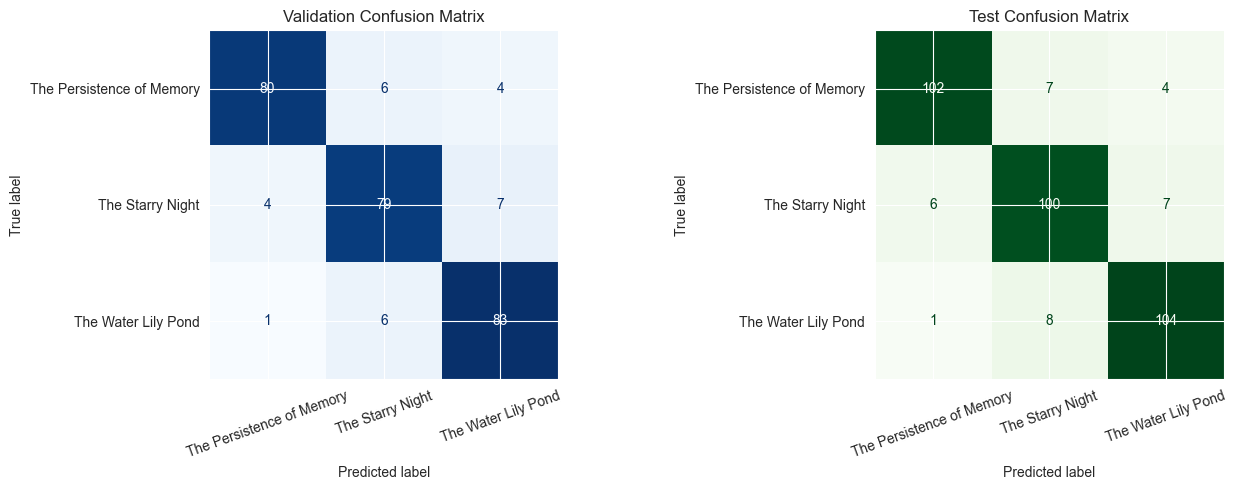

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

val_cm = confusion_matrix(prepared.y_val, best_result["val_predictions"])
test_cm = confusion_matrix(prepared.y_test, best_result["test_predictions"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(
    confusion_matrix=val_cm,
    display_labels=prepared.class_names,
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Validation Confusion Matrix")
axes[0].tick_params(axis="x", rotation=20)

ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=prepared.class_names,
).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Test Confusion Matrix")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()
